# Module 03: EDA

In [86]:
# packages
import numpy as np 
import matplotlib.pyplot as plt
from matplotlib.pyplot import subplots
from sklearn.model_selection import train_test_split 
from ISLP import load_data

# set seed
seed = 2323

### We'll use the _Hitters_ data from ISLP for this activity. The metadata for _Hitters_ can be found [here](https://intro-stat-learning.github.io/ISLP/datasets/Hitters.html).

In [87]:
# Load the data
Hitters = load_data('Hitters')

### Determine the number of rows and columns in the dataset by returning its "shape" attribute

In [88]:
Hitters.shape

(322, 20)

### Determine whether each feature is numeric or categorical by returning the "dtype" attribute for each column

In [89]:
for col in Hitters.columns:
    if Hitters[col].dtype == int:
        print(f"{col} is Numeric")
    elif Hitters[col].dtype == float:
        print(f"{col} is Numeric")
    else:
        print(f"{col} is Categorical")



AtBat is Numeric
Hits is Numeric
HmRun is Numeric
Runs is Numeric
RBI is Numeric
Walks is Numeric
Years is Numeric
CAtBat is Numeric
CHits is Numeric
CHmRun is Numeric
CRuns is Numeric
CRBI is Numeric
CWalks is Numeric
League is Categorical
Division is Categorical
PutOuts is Numeric
Assists is Numeric
Errors is Numeric
Salary is Numeric
NewLeague is Categorical


### Before doing any other analyses, let's create training and test sets.

In [90]:
Train, Test = train_test_split(Hitters, 
                               random_state=seed, 
                               test_size=0.40, 
                               shuffle=True) 

### Based on the metadata, what is the difference between the 6 columns starting with 'C' and the 6 related columns that don't?

The C columns are career totals, and are therefore much higher than their related columns which are just for the given year unless it is the players first year in the league.

### On the training set, create pairwise scatterplots for each of these 6 columns with the 'Salary' variable.

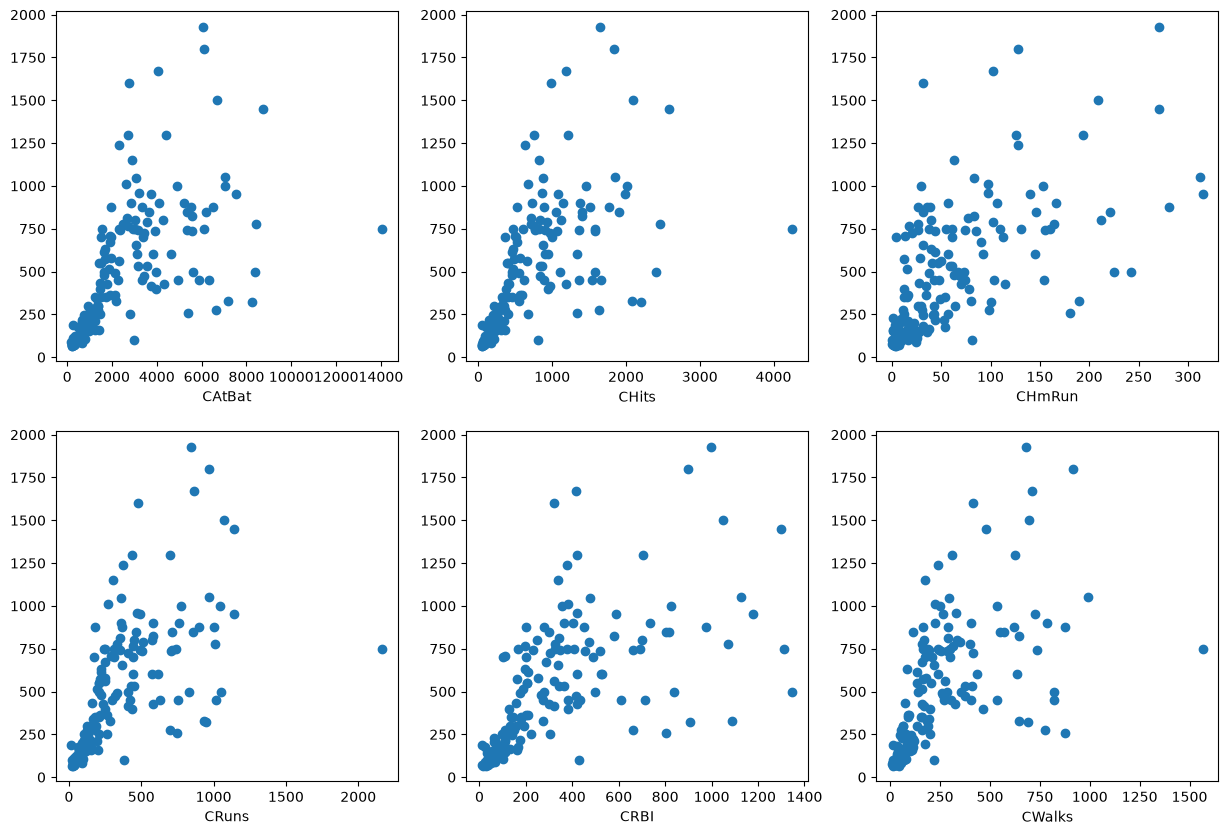

In [91]:
# First create a subset of the columns that we want to plot

subset = Train[['CAtBat', 'CHits', 'CHmRun', 'CRuns', 'CRBI', 'CWalks']]

# Initialize the plots before drawing them

fig, axes = subplots(nrows=2,
                     ncols=3,
                     figsize=(15, 10))
# Copy the helper function

def range_to_grid(i,Ncol):
    x=[]
    y=[]
    for n in range(Ncol**2):
        x.append(int(np.floor(n/Ncol)))
        y.append(n % Ncol)
        #print(n,x[n],y[n])
    return x[i],y[i]

# Plot the variables

for j in range(len(subset.columns)):
    axes[range_to_grid(j,3)[0],range_to_grid(j,3)[1]].plot(subset.iloc[:,j], Train['Salary'], 'o')
    axes[range_to_grid(j,3)[0],range_to_grid(j,3)[1]].set_xlabel(subset.columns[j])


### Use the "describe" method to determine the mean, standard deviation, and 5 number summary of all numeric variables in the training subset of _Hitters_.

In [92]:
Train.describe()

,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary
count,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,193.000000,164.000000
mean,381.829016,101.549223,10.150259,50.751295,47.093264,38.445596,7.253886,2587.440415,702.222798,59.668394,345.378238,308.373057,248.388601,276.865285,105.300518,8.051813,493.032951
std,145.679181,44.267521,8.228711,24.784284,24.912589,21.136915,4.858712,2285.947344,649.010165,66.449102,322.848870,297.885894,250.777436,262.957701,137.135778,6.783667,386.159522
min,19.000000,7.000000,0.000000,1.000000,2.000000,1.000000,1.000000,41.000000,13.000000,0.000000,3.000000,4.000000,4.000000,0.000000,0.000000,0.000000,67.500000
25%,271.000000,68.000000,4.000000,32.000000,29.000000,22.000000,3.000000,730.000000,185.000000,14.000000,98.000000,82.000000,63.000000,109.000000,7.000000,3.000000,160.000000
50%,369.000000,95.000000,8.000000,47.000000,43.000000,34.000000,6.000000,1876.000000,476.000000,36.000000,238.000000,202.000000,166.000000,211.000000,38.000000,6.000000,420.833500
75%,508.000000,136.000000,14.000000,68.000000,61.000000,53.000000,11.000000,3754.000000,1000.000000,78.000000,494.000000,419.000000,332.000000,317.000000,173.000000,12.000000,750.000000
max,687.000000,223.000000,40.000000,130.000000,121.000000,105.000000,24.000000,14053.000000,4256.000000,315.000000,2165.000000,1348.000000,1566.000000,1320.000000,492.000000,32.000000,1925.571000


### It looks like the mean and median of 'AtBat' are nearly equal. This _might_ suggest that this variable is normally distributed. Create a histogram of 'AtBat' to check this hypothesis.

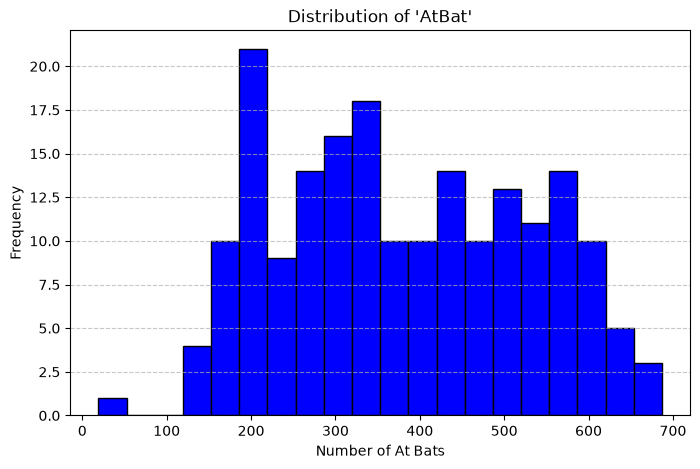

In [93]:
at_bat_data = Train["AtBat"].dropna()

fig, ax = subplots(figsize=(8, 5))

ax.hist(at_bat_data, bins=20, color="blue", edgecolor="black")

ax.set_title("Distribution of 'AtBat'")
ax.set_xlabel("Number of At Bats")
ax.set_ylabel("Frequency")
ax.grid(axis="y", linestyle="--", alpha=0.7)

### Let's standardize the AtBat feature (i.e., normalize by z-scores). We'll create a new column in the training data called 'AtBat_st' to represent this.

In [94]:
Train['AtBat_st'] = (Train['AtBat'] - Train["AtBat"].mean()) / Train["AtBat"].std()

### How many rows have an 'AtBat' value within the first standard deviation?

Hint: the 'len' magic method returns the number of rows of a dataFrame.

In [95]:
len(Train[(Train['AtBat_st'] < 1) & (Train['AtBat_st'] > -1)])

115

### Going back to the results of the 'describe' method, how can you tell that the 'Salary' variable has missing values?

All of the other variables have a count of 193, while the salary variable has a count of 164, which shows that 29 observations in the training data are missing salary values.

### Describe a situation where a variable could have missing values but this would not be reflected in the results of the 'describe' method.

The missing value may have a placeholder, like 0 or -999, that allows the describe function to include it without a meaningful value being present. This could also skew other parts of the descirbe function, like the mean, making the function unreliable overall.

### On the training data, create separate boxplots of the 'AtBat' variable for when 'Salary' is populated or missing.

[(0.5, 2.5)]

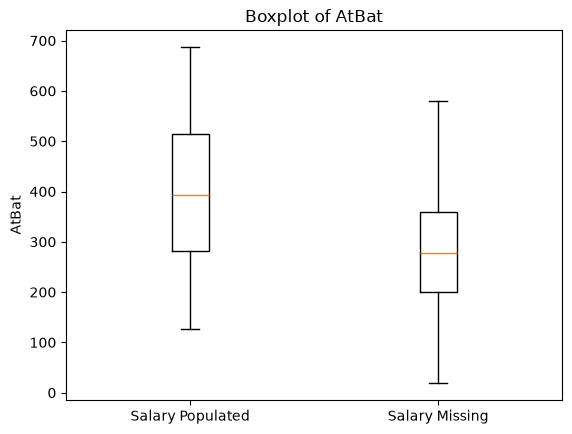

In [96]:
#fill in
salary = Train[Train["Salary"].notnull()]
nonsalary = Train[Train["Salary"].isnull()]

fig, ax = plt.subplots()
ax.boxplot([salary["AtBat"], 
            nonsalary["AtBat"]], 
           positions = [1, 2])
ax.set_title("Boxplot of AtBat")
ax.set_ylabel("AtBat")
ax.set_xticklabels(["Salary Populated", "Salary Missing"])
ax.set(xlim=(0.5, 2.5))




### Create a correlation matrix for all numeric features in the training set

In [97]:
numeric_train = Train.select_dtypes(include=[np.number])
corr_matrix = numeric_train.corr()
corr_matrix


,AtBat,Hits,HmRun,Runs,RBI,Walks,Years,CAtBat,CHits,CHmRun,CRuns,CRBI,CWalks,PutOuts,Assists,Errors,Salary,AtBat_st
AtBat,1.000000,0.963324,0.540323,0.906579,0.798717,0.631824,-0.039232,0.126602,0.146763,0.150166,0.164892,0.145779,0.056578,0.345879,0.363085,0.368162,0.401390,1.000000
Hits,0.963324,1.000000,0.516853,0.914739,0.795316,0.605876,-0.028717,0.133316,0.163329,0.136865,0.175542,0.153011,0.065178,0.312858,0.310422,0.301725,0.432558,0.963324
HmRun,0.540323,0.516853,1.000000,0.618439,0.840613,0.385425,0.009072,0.078981,0.076914,0.411917,0.110767,0.218285,0.080296,0.222084,-0.069088,0.062840,0.326021,0.540323
Runs,0.906579,0.914739,0.618439,1.000000,0.786635,0.711346,-0.069584,0.083770,0.103859,0.160979,0.159683,0.115628,0.099025,0.289952,0.184714,0.217297,0.441499,0.906579
RBI,0.798717,0.795316,0.840613,0.786635,1.000000,0.553527,0.046705,0.165837,0.180526,0.375072,0.191452,0.285074,0.117109,0.323825,0.138896,0.217983,0.414623,0.798717
Walks,0.631824,0.605876,0.385425,0.711346,0.553527,1.000000,0.037943,0.137157,0.147019,0.194766,0.205250,0.167453,0.312812,0.317000,0.139008,0.160753,0.458462,0.631824
Years,-0.039232,-0.028717,0.009072,-0.069584,0.046705,0.037943,1.000000,0.925308,0.906857,0.730478,0.882559,0.882835,0.836809,0.071301,-0.091915,-0.160476,0.541390,-0.039232
CAtBat,0.126602,0.133316,0.078981,0.083770,0.165837,0.137157,0.925308,1.000000,0.995185,0.775167,0.979705,0.948617,0.894573,0.120875,-0.000507,-0.068187,0.616677,0.126602
CHits,0.146763,0.163329,0.076914,0.103859,0.180526,0.147019,0.906857,0.995185,1.000000,0.761920,0.983128,0.945002,0.883547,0.132818,-0.003372,-0.062669,0.629875,0.146763
CHmRun,0.150166,0.136865,0.411917,0.160979,0.375072,0.194766,0.730478,0.775167,0.761920,1.000000,0.782490,0.912134,0.750795,0.126756,-0.129640,-0.141514,0.616170,0.150166


### Propose two different ways of imputing the missing values of Salary while taking advantage of the information given in the boxplots or the correlation matrix.

One idea would be to fill in the salary value in missing places with the average of salaries in a given bucket. I would recommend using one the C stats to make the buckets because they have the highest correlation to salary in the correlation matrix. 

Another idea would be to create a multiple linear regression model to try and predict where thes observations with missing salaries would fit into the data using the variables present for every observation.

### For our last exercise, we'll explore Hits and Walks relative to AtBat totals. 
- Use the sum function to calculuate the totals of each of these three variables for the 1986 season (on the training set). 
- Create a pie chart which shows total hits, total walks, and remaining total (neither) as percents of the At Bats total (on the training set). 

In [98]:
TotHits = sum(Train['CHits'])
TotWalks = sum(Train['CWalks'])
TotAtBat = sum(Train['CAtBat'])

Labels = ['Hits', 'Walks', 'Neither']
Totals = [TotHits, TotWalks, TotAtBat-TotHits-TotWalks]

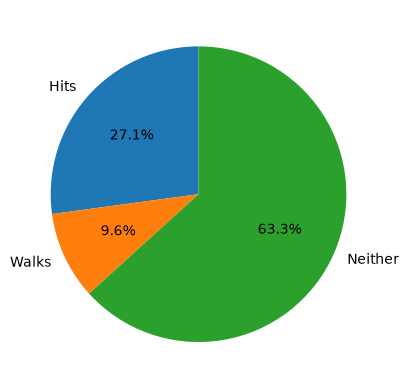

In [99]:
# pie chart
plt.pie(Totals, labels=Labels, autopct='%1.1f%%', startangle=90)
plt.show()

### The previous two cells gave us totals across all players. For each player in the training set, calculate the Hits as a percent of AtBat and store it in a new variable called 'AVG'

In [100]:
#fillin
Train['AVG'] = Train['Hits'] / Train['AtBat']

### Using 0.25 and 0.31 as the split points, create a new variable with three bins: high, medium, and low. 

In [101]:
Train['AVG_bin'] = 'medium'
Train['AVG_bin'] = np.where(Train['AVG'] < 0.25, 'low', Train['AVG_bin'])
Train['AVG_bin'] = np.where(Train['AVG'] > 0.31, 'high', Train['AVG_bin'])


### Create a bar chart that displays the number of players in each of the low, medium, and high categories (for the training data).

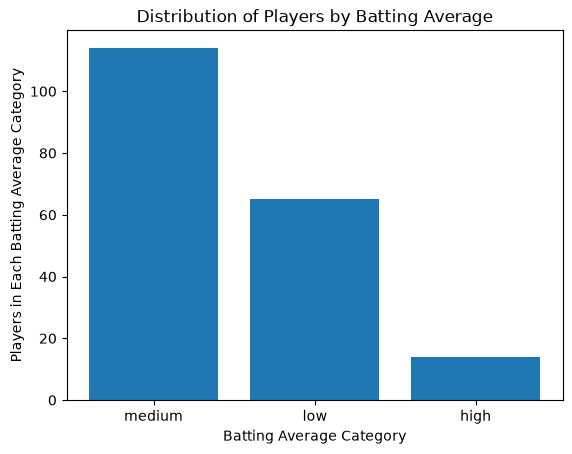

In [102]:
Train['AVG_bin'].value_counts()

plt.bar(Train['AVG_bin'].value_counts().index, Train['AVG_bin'].value_counts().values)
plt.ylabel('Players in Each Batting Average Category')
plt.xlabel('Batting Average Category')
plt.title('Distribution of Players by Batting Average')
plt.show()

Notice that the order of the bars will be medium, low, high. That's counterintuitive. We can reorder these quickly. 

In [103]:
indexMap = ['low', 'medium', 'high']
reordered_list = [Train['AVG_bin'].value_counts()[i] for i in indexMap]

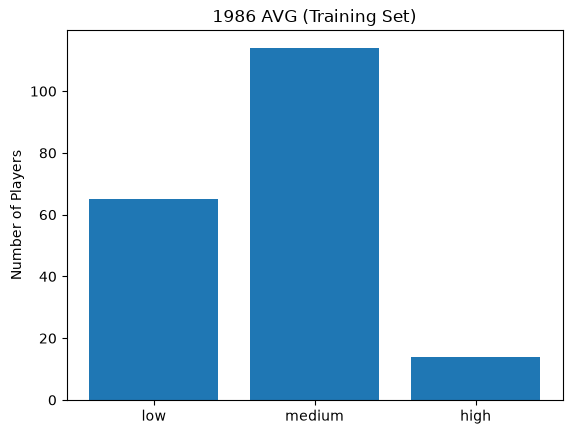

In [104]:
plt.bar(indexMap, reordered_list)

plt.title("1986 AVG (Training Set)")
plt.ylabel("Number of Players")

plt.xticks(indexMap)

plt.show()

### Did we use the depth method or width method for creating these bins? Explain.

This is a width model. The main characteristic of a depth model is that there is the same or very similar amounts of observations in each bin. This model has over 115 observations in the 'medium' bin, around 65 in the 'low' bin and about 15 in the 'high' bin. These are obviously very different amount, therefore this is a width model. Also, if we look at the describe function after adding the batting average variable, the minimum is .19 and the max is .35. Therefore, by putting the bin sizes at .25 and .31, we have covered roughly .05 with each bin.